In [1]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import colors as mcolors

In [2]:
edges_df = pd.read_csv("enron_weighted_edges.csv")
# remove self-loops
edges_df = edges_df[edges_df['Source'] != edges_df['Target']]

# Get the full network
G_full = (nx.from_pandas_edgelist
    (edges_df,
    source='Source',
    target='Target',
    edge_attr='Weight',
    create_using=nx.DiGraph()))
print(f"Enron dataset: {G_full.number_of_nodes()} nodes, {G_full.number_of_edges()} edges")

Enron dataset: 56595 nodes, 226837 edges


In [3]:
# get subgraph of active user with degree >= 10
nodes_to_keep = [node for node, degree in G_full.degree() if degree >= 10]
G = G_full.subgraph(nodes_to_keep).copy()

print(f"Filtered Graph (Degree >= 10): {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")

Filtered Graph (Degree >= 10): 6347 nodes, 140501 edges


In [4]:
density_full = nx.density(G_full)
density_filtered = nx.density(G)

print(f"Directed density (G_full): {density_full:.8f}")
print(f"Directed density (G, degree>=10): {density_filtered:.8f}")

Directed density (G_full): 0.00007082
Directed density (G, degree>=10): 0.00348828


In [5]:
# Weighted density for directed graph:
# weighted_density = sum(edge weights) / (n * (n - 1))

def weighted_density_directed(graph, weight_key='Weight'):
    n = graph.number_of_nodes()
    if n < 2:
        return 0.0

    total_possible_directed_edges = n * (n - 1)
    total_weight = sum(float(data.get(weight_key, 0.0)) for _, _, data in graph.edges(data=True))
    return total_weight / total_possible_directed_edges


wd_full = weighted_density_directed(G_full)
wd_filtered = weighted_density_directed(G)

print(f"Weighted density (G_full): {wd_full:.8f}")
print(f"Weighted density (G, degree>=10): {wd_filtered:.8f}")

Weighted density (G_full): 0.00030214
Weighted density (G, degree>=10): 0.01878353


Average In-Degree: 22.14
Average Out-Degree: 22.14


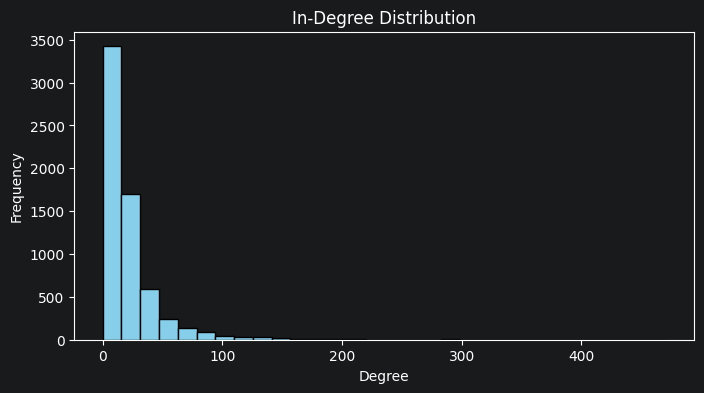

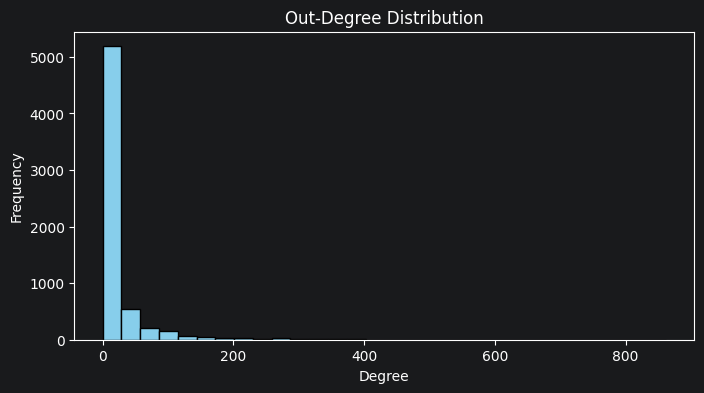

In [6]:
# In-degree and Out-degree distributions
in_degrees = [d for n, d in G.in_degree()]
out_degrees = [d for n, d in G.out_degree()]

avg_in_degree = np.mean(in_degrees)
avg_out_degree = np.mean(out_degrees)

print(f"Average In-Degree: {avg_in_degree:.2f}")
print(f"Average Out-Degree: {avg_out_degree:.2f}")

def plot_dist(data, title):
    plt.figure(figsize=(8, 4))
    plt.hist(data, bins=30, color='skyblue', edgecolor='black')
    plt.title(title)
    plt.xlabel('Degree')
    plt.ylabel('Frequency')
    plt.show()

plot_dist(in_degrees, "In-Degree Distribution")
plot_dist(out_degrees, "Out-Degree Distribution")

In [7]:
# Average Clustering Coefficient
avg_clustering = nx.average_clustering(G)
print(f"Average Clustering Coefficient: {avg_clustering:.4f}")

Average Clustering Coefficient: 0.2863


In [ ]:
# Betweenness Centrality
betweenness = nx.betweenness_centrality(G, weight='Weight')
# Closeness Centrality
closeness = nx.closeness_centrality(G)

In [ ]:
# Results
stats_df = pd.DataFrame({
    'Node_ID': list(betweenness.keys()),
    'Betweenness': list(betweenness.values()),
    'Closeness': list(closeness.values()),
    'In_Degree': [G.in_degree(n) for n in G.nodes()],
    'Out_Degree': [G.out_degree(n) for n in G.nodes()]
})

print("Top Influential Nodes by Betweenness:")
top = stats_df.sort_values(by='Betweenness', ascending=False).head(10).reset_index(drop=True)
print(top)

In [ ]:
mapping_df = pd.read_csv("id_mapping.csv")
full_stats_with_names = stats_df.merge(mapping_df, left_on='Node_ID', right_on='ID')
full_stats_with_names = full_stats_with_names.drop(columns=['ID'])
top_10_labeled = full_stats_with_names.sort_values(by='Betweenness', ascending=False).head(10).reset_index(drop=True)
print("--- Top 10 Enron Nodes by Betweenness ---")
print(top_10_labeled[['Email_Address', 'Node_ID', 'Betweenness', 'In_Degree', 'Out_Degree']])

In [ ]:
full_stats_with_names['Total_Degree'] = full_stats_with_names['In_Degree'] + full_stats_with_names['Out_Degree']
top_10_total_degree = full_stats_with_names.sort_values(by='Total_Degree', ascending=False).head(10).reset_index(
    drop=True)

print("--- Top 10 Enron Nodes by Total Degree ---")
print(top_10_total_degree[['Node_ID', 'Email_Address', 'Total_Degree', 'In_Degree', 'Out_Degree']])

In [ ]:
# Top 10 by Closeness Centrality
top_10_closeness = (
full_stats_with_names.sort_values(by='Closeness', ascending=False).head(10).reset_index(drop=True))

print("--- Top 10 Enron Nodes by Closeness ---")
print(top_10_closeness[['Email_Address', 'Node_ID', 'Closeness', 'In_Degree', 'Out_Degree']])

In [ ]:
all_scores = sorted(stats_df['Betweenness'], reverse=True)
plt.figure(figsize=(10, 4))
plt.plot(all_scores[:200])
plt.title("Betweenness Centrality Scores of Top 200 Nodes")
plt.xlabel("Nodes")
plt.ylabel("Betweenness Centrality")
plt.show()

In [ ]:
plt.figure(figsize=(10, 5))
plt.hist(stats_df['Closeness'], bins=30, color='blueviolet', edgecolor='black', alpha=0.9)
plt.title("Closeness Centrality Distribution")
plt.xlabel("Closeness Centrality")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

In [ ]:
plt.scatter(stats_df['Closeness'], stats_df['Betweenness'], alpha=0.5)
plt.title("Closeness vs. Betweenness Centrality")
plt.xlabel("Closeness Score")
plt.ylabel("Betweenness Score")
plt.show()